# Electricity Price Analysis in France 🇫🇷

## 🎯 Objective
This project investigates the key drivers of electricity price fluctuations in France, focusing on demand patterns and renewable energy production.

## ❓ Key Questions
- What temporal patterns (hourly, weekly, seasonal) affect electricity prices?
- How do demand (load) and renewable generation (wind, solar) influence prices?
- What conditions lead to extreme price spikes?

## 📊 Dataset
- Electricity price (EUR/MWh)
- Load (demand)
- Wind generation
- Solar generation

Time resolution: hourly

## 01 - Data Preparation

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno

import sys
sys.path.append("../src")
import style 
style.apply_style()

pd.set_option("display.max_columns", 50)

In [3]:
price_files = sorted(glob.glob("../data/raw/GUI_ENERGY_PRICES_*.csv"))
load_files = sorted(glob.glob("../data/raw/GUI_TOTAL_LOAD_DAYAHEAD_*.csv"))
wind_off_shore_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_OFFSHORE_*.csv"))
wind_on_shore_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_*.csv"))
solar_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_*.csv"))

In [4]:
def read_to_df(file):
    dfs = []
    for f in file:
        df = pd.read_csv(f)
        dfs.append(df)
    df_concat = pd.concat(dfs)
    return df_concat

In [5]:
df1 = read_to_df(price_files[0:9])
df2 = read_to_df(load_files[0:9])
df3 = read_to_df(wind_off_shore_files[0:9])
df4 = read_to_df(wind_on_shore_files[0:9])
df5 = read_to_df(solar_files[0:9])

In [6]:
df1.drop(["Sequence", "Intraday Period (CET/CEST)", "Intraday Price (EUR/MWh)"], axis = 1, inplace = True)
df1.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41


In [7]:
df2.drop("Area", axis = 1, inplace = True)
df2.head()

,MTU (CET/CEST),Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2016 00:00 - 01/01/2016 01:00,58639.0,58600.0
1,01/01/2016 01:00 - 01/01/2016 02:00,56733.0,56550.0
2,01/01/2016 02:00 - 01/01/2016 03:00,55127.0,56150.0
3,01/01/2016 03:00 - 01/01/2016 04:00,51744.0,52600.0
4,01/01/2016 04:00 - 01/01/2016 05:00,51744.0,49750.0


In [8]:
def format_mtu(mtu_string):
    start, end = mtu_string.split(" - ")
    
    def process_part(part):
        # Extract timezone if exists
        match = re.match(r"(.+?)(\s\(.+\))?$", part)
        datetime_part = match.group(1)
        tz_part = match.group(2) if match.group(2) else ""
        
        # Convert to datetime and format with seconds
        dt = pd.to_datetime(datetime_part, format="%d/%m/%Y %H:%M")
        return dt.strftime("%d/%m/%Y %H:%M:%S") + tz_part
    
    return process_part(start) + " - " + process_part(end)

df2["MTU (CET/CEST)"] = df2["MTU (CET/CEST)"].apply(format_mtu)

df2.head()

,MTU (CET/CEST),Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,58639.0,58600.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,56733.0,56550.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,55127.0,56150.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,51744.0,52600.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,51744.0,49750.0


In [9]:
df3.drop("Area", axis = 1, inplace = True)
df3[["Day-ahead (MW)", "Intraday (MW)", "Actual (MW)"]] = df3[["Day-ahead (MW)", "Intraday (MW)", "Actual (MW)"]].replace("n/e", np.nan)
df3.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,NaN,NaN,,NaN
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,NaN,NaN,,NaN
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,NaN,NaN,,NaN
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,NaN,NaN,,NaN
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,NaN,NaN,,NaN


In [10]:
df4.drop("Area", axis = 1, inplace = True)
df4.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,2313.42,NaN,,2189.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,2003.04,NaN,,1753.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,1743.72,NaN,,1430.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,1490.09,NaN,,1214.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,1238.09,NaN,,1031.0


In [11]:
df5.drop("Area", axis = 1, inplace = True)
df5.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,0.0,NaN,,0.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,0.0,NaN,,0.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,0.0,NaN,,0.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,0.0,NaN,,0.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,0.0,NaN,,0.0


## 🧹 Data Cleaning
- Merged datasets into a unified time index
- Handled missing timestamps due to daylight saving transitions

In [12]:
df_alls_original = df1.merge(df2.rename(columns = lambda c : c if c == "MTU (CET/CEST)" else c+"_load"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df3.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_wind_offshore"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df4.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_wind_onshore"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df5.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_solar"), on = "MTU (CET/CEST)", how = "outer")
df_alls_original.shape

(78912, 17)

In [13]:
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,,NaN,2313.42,NaN,,2189.0,0.0,NaN,,0.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,,NaN,2003.04,NaN,,1753.0,0.0,NaN,,0.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,,NaN,1743.72,NaN,,1430.0,0.0,NaN,,0.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,,NaN,1490.09,NaN,,1214.0,0.0,NaN,,0.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,,NaN,1238.09,NaN,,1031.0,0.0,NaN,,0.0


Extracting the MTU and set the starting time as dataframe index "timestamp".

In [14]:
start_str = (
    df_alls_original.iloc[:, 0]
      .str.split(" - ").str[0]
      .str.replace(r"\s*\(.*\)$", "", regex=True)
)

df_alls_original["timestamp"] = pd.to_datetime(
    start_str,
    format="%d/%m/%Y %H:%M:%S"
)
df_alls_original = df_alls_original.set_index("timestamp").sort_index()
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,,NaN,2313.42,NaN,,2189.0,0.0,NaN,,0.0
2016-01-01 01:00:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,,NaN,2003.04,NaN,,1753.0,0.0,NaN,,0.0
2016-01-01 02:00:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,,NaN,1743.72,NaN,,1430.0,0.0,NaN,,0.0
2016-01-01 03:00:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,,NaN,1490.09,NaN,,1214.0,0.0,NaN,,0.0
2016-01-01 04:00:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,,NaN,1238.09,NaN,,1031.0,0.0,NaN,,0.0


In [15]:
df_alls_original.index.is_monotonic_increasing

True

In [16]:
df_alls_original.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78912 entries, 2016-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   MTU (CET/CEST)                           78912 non-null  object 
 1   Area                                     78912 non-null  object 
 2   Day-ahead Price (EUR/MWh)                78912 non-null  float64
 3   Actual Total Load (MW)_load              78825 non-null  float64
 4   Day-ahead Total Load Forecast (MW)_load  78912 non-null  float64
 5   Day-ahead (MW)_wind_offshore             12313 non-null  object 
 6   Intraday (MW)_wind_offshore              12329 non-null  object 
 7   Current (MW)_wind_offshore               78912 non-null  object 
 8   Actual (MW)_wind_offshore                13509 non-null  object 
 9   Day-ahead (MW)_wind_onshore              78397 non-null  float64
 10  Intraday (M

In [17]:
col_object = ["Day-ahead (MW)_wind_offshore", 
              "Intraday (MW)_wind_offshore", 
              "Current (MW)_wind_offshore", 
              "Actual (MW)_wind_offshore", 
              "Current (MW)_wind_onshore", 
              "Current (MW)_solar"]

for col in col_object:
    df_alls_original[col] = pd.to_numeric(df_alls_original[col], errors = "coerce")

In [18]:
df_alls_original[df_alls_original.index.duplicated()].sort_index()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-10-30 02:00:00,30/10/2016 02:00:00 (CEST) - 30/10/2016 02:00:...,BZN|FR,47.93,NaN,48200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2326.0,NaN,NaN,NaN,0.0
2017-10-29 02:00:00,29/10/2017 02:00:00 (CEST) - 29/10/2017 02:00:...,BZN|FR,15.41,NaN,46700.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6281.0,NaN,NaN,NaN,0.0
2018-10-28 02:00:00,28/10/2018 02:00:00 (CEST) - 28/10/2018 02:00:...,BZN|FR,52.40,NaN,51000.0,NaN,NaN,NaN,NaN,3246.00,NaN,3763.00,NaN,0.0,0.0,0.0,0.0
2019-10-27 02:00:00,27/10/2019 02:00:00 (CEST) - 27/10/2019 02:00:...,BZN|FR,21.13,NaN,41300.0,NaN,NaN,NaN,NaN,4699.39,NaN,4699.39,NaN,NaN,NaN,NaN,NaN
2020-10-25 02:00:00,25/10/2020 02:00:00 (CET) - 25/10/2020 03:00:00,BZN|FR,0.09,40218.0,41100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9925.0,NaN,NaN,NaN,0.0
2021-10-31 02:00:00,31/10/2021 02:00:00 (CEST) - 31/10/2021 02:00:...,BZN|FR,74.78,NaN,43100.0,NaN,NaN,NaN,NaN,5208.84,NaN,5208.84,4516.0,NaN,NaN,0.0,0.0
2022-10-30 02:00:00,30/10/2022 02:00:00 (CET) - 30/10/2022 03:00:00,BZN|FR,100.15,32296.0,34100.0,NaN,NaN,NaN,NaN,3788.08,2980.43,2980.43,3161.0,0.0,0.0,0.0,0.0
2023-10-29 02:00:00,29/10/2023 02:00:00 (CEST) - 29/10/2023 02:00:...,BZN|FR,0.02,39130.0,38100.0,467.0,467.0,467.0,698.0,15505.55,16046.94,16046.94,14035.0,0.0,0.0,0.0,0.0
2024-10-27 02:00:00,27/10/2024 02:00:00 (CEST) - 27/10/2024 02:00:...,BZN|FR,82.23,37085.0,36600.0,197.0,197.0,197.0,115.0,2257.03,2042.05,2239.05,1884.0,0.0,0.0,0.0,0.0


In [19]:
df_alls_original.index.to_series().diff().value_counts()

timestamp
0 days 01:00:00    78893
0 days 02:00:00        9
0 days 00:00:00        9
Name: count, dtype: int64

The raw dataset contains mixed 0-hour and 1-hour intervals, due to DST-induced duplicates (autumn fallbacks and spring forwards)

Use pandas tz_localize method to resolve dst duplicate timestamps prior to analysis.

In [20]:
df_alls_original.groupby(df_alls_original.index.year).apply(
    lambda x: x.index.to_series().diff().value_counts()
)

timestamp,0 days 01:00:00,0 days 02:00:00,0 days 00:00:00
timestamp,,,
2016,8781,1,1
2017,8757,1,1
2018,8757,1,1
2019,8757,1,1
2020,8781,1,1
2021,8757,1,1
2022,8757,1,1
2023,8757,1,1
2024,8781,1,1


In [21]:
df_alls_original = df_alls_original.tz_localize(
    "Europe/Paris",
    ambiguous = "infer",
    nonexistent = "shift_forward"
)
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+01:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,NaN,NaN,2313.42,NaN,NaN,2189.0,0.0,NaN,NaN,0.0
2016-01-01 01:00:00+01:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,NaN,NaN,2003.04,NaN,NaN,1753.0,0.0,NaN,NaN,0.0
2016-01-01 02:00:00+01:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,NaN,NaN,1743.72,NaN,NaN,1430.0,0.0,NaN,NaN,0.0
2016-01-01 03:00:00+01:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,NaN,NaN,1490.09,NaN,NaN,1214.0,0.0,NaN,NaN,0.0
2016-01-01 04:00:00+01:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,NaN,NaN,1238.09,NaN,NaN,1031.0,0.0,NaN,NaN,0.0


In [22]:
df_alls_original[df_alls_original.index.duplicated()]

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,


In [23]:
df_alls_original.describe()

,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
count,78912.000000,78825.000000,78912.000000,12313.000000,12329.000000,12329.000000,13479.000000,78397.000000,48475.000000,58501.000000,78886.000000,78364.000000,48200.000000,58423.000000,78893.000000
mean,82.573143,52011.035156,52082.498517,377.557054,377.875253,377.675744,375.582154,3894.447858,4469.708358,4380.682125,3818.483841,1642.841899,2267.507743,1886.211840,1609.394446
std,95.270461,11378.370330,11548.198555,342.820843,343.842685,343.902826,335.621374,3143.593806,3540.563455,3426.459406,2998.673035,2543.435498,2926.373185,2807.293305,2430.182974
min,-134.940000,28744.000000,27650.000000,0.000000,0.000000,0.000000,0.000000,185.090000,131.760000,149.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,43441.000000,43350.000000,101.500000,102.500000,102.250000,103.000000,1700.920000,1899.140000,1898.990000,1623.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,50206.000000,50250.000000,277.500000,276.500000,276.250000,281.000000,2865.210000,3288.620000,3241.100000,2814.000000,16.415000,748.420000,23.690000,223.000000
75%,89.920000,59524.000000,59750.000000,558.750000,561.750000,562.000000,566.000000,5064.990000,6005.750000,5847.690000,5173.000000,2736.867500,3991.787500,3320.680000,2608.000000
max,2987.780000,94492.000000,95150.000000,1406.250000,1421.250000,1421.250000,1442.000000,20156.400000,20292.270000,20256.850000,17919.000000,15323.460000,15313.240000,15499.530000,15066.000000


In [25]:
day_ahead_renew = ["Day-ahead (MW)_wind_offshore", 
                   "Day-ahead (MW)_wind_onshore",
                   "Day-ahead (MW)_solar"]
for col in day_ahead_renew:
    df_alls_original[col] = df_alls_original[col].fillna(0)

In [27]:
for col in df_alls_original.columns:
    print(col, "--", df_alls_original[col].dtype)

MTU (CET/CEST) -- object
Area -- object
Day-ahead Price (EUR/MWh) -- float64
Actual Total Load (MW)_load -- float64
Day-ahead Total Load Forecast (MW)_load -- float64
Day-ahead (MW)_wind_offshore -- float64
Intraday (MW)_wind_offshore -- float64
Current (MW)_wind_offshore -- float64
Actual (MW)_wind_offshore -- float64
Day-ahead (MW)_wind_onshore -- float64
Intraday (MW)_wind_onshore -- float64
Current (MW)_wind_onshore -- float64
Actual (MW)_wind_onshore -- float64
Day-ahead (MW)_solar -- float64
Intraday (MW)_solar -- float64
Current (MW)_solar -- float64
Actual (MW)_solar -- float64


In [28]:
df_alls_original.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78912 entries, 2016-01-01 00:00:00+01:00 to 2024-12-31 23:00:00+01:00
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   MTU (CET/CEST)                           78912 non-null  object 
 1   Area                                     78912 non-null  object 
 2   Day-ahead Price (EUR/MWh)                78912 non-null  float64
 3   Actual Total Load (MW)_load              78825 non-null  float64
 4   Day-ahead Total Load Forecast (MW)_load  78912 non-null  float64
 5   Day-ahead (MW)_wind_offshore             78912 non-null  float64
 6   Intraday (MW)_wind_offshore              12329 non-null  float64
 7   Current (MW)_wind_offshore               12329 non-null  float64
 8   Actual (MW)_wind_offshore                13479 non-null  float64
 9   Day-ahead (MW)_wind_onshore              78912 non-null  float64
 10 

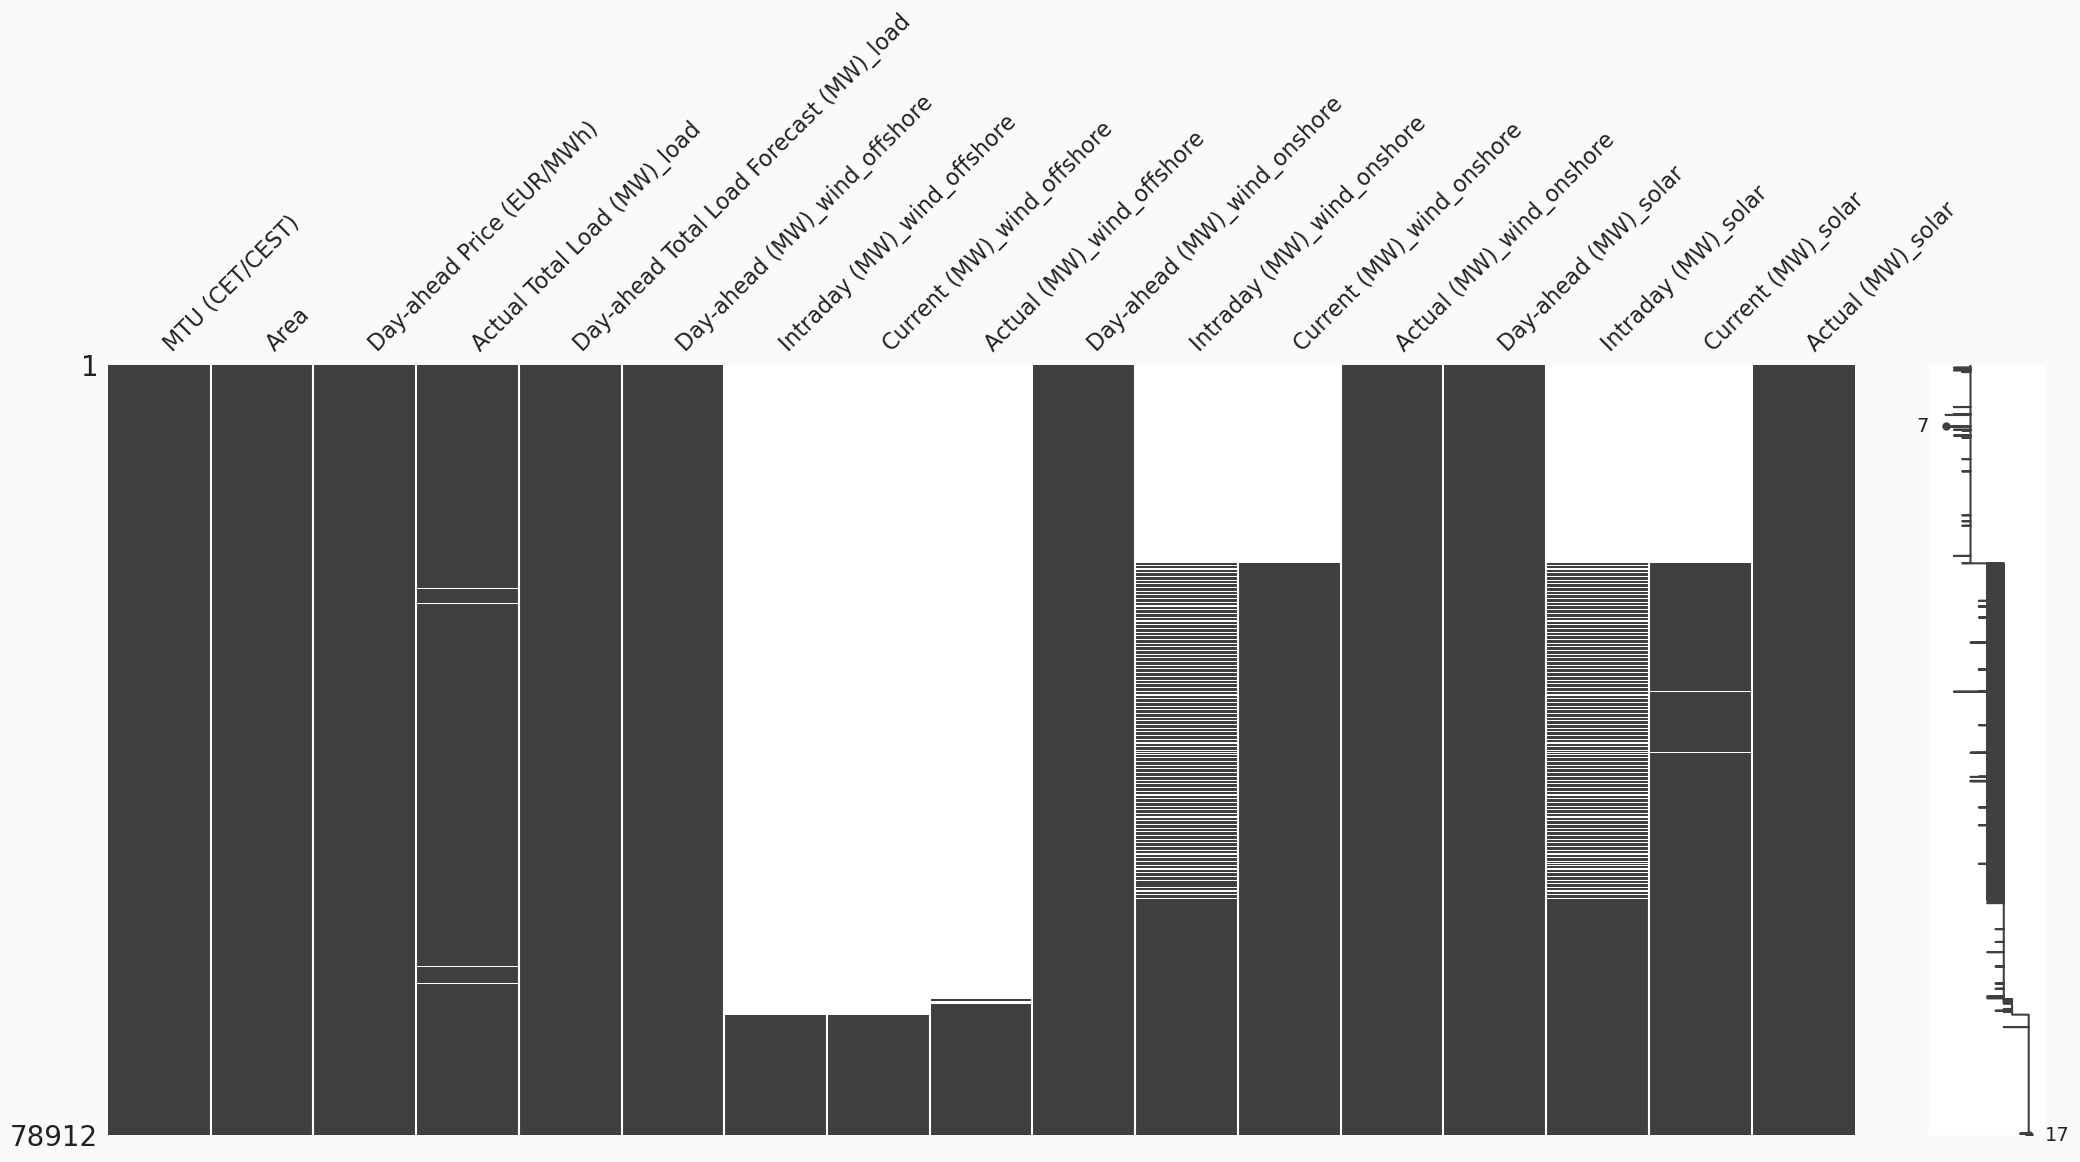

In [30]:
msno.matrix(df_alls_original)
plt.show()

In [31]:
import pyarrow 
df_alls_original.to_parquet("../data/processed/df_alls_cleaned.parquet", index = True)

## Summary
The original data is consisted of five individual csv files, where each corresponds to prices, total load, wind offshore generations, wind onshore generations and solar generations. 

After extracting relevant columns of these five files, they have been merged into one dataframe. However, the merged dataframe has only the conventional time indications, and no timestamp column, which is essential for electricity price analysis.  

Therefore the time column is dealt with time zone issues and autumn/spring clock reset before being tranformed into the dataframe with proper timestamp column. 

The relevant columns are also examined and eliminated NaN values. The dataframe is then saved as parquet format, which is prepared for further explorations. 